In [5]:
import qiskit
from qiskit import QuantumCircuit
import qiskit.quantum_info as qi
from qiskit.compiler import transpile
from qiskit.circuit.library import StatePreparation
from qiskit.primitives import StatevectorSampler
from qiskit import QuantumRegister, AncillaRegister
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import json
import numpy as np

In [34]:
import scipy as sp

In [6]:
import Hamiltonian as hm

This notebook is coding in a classical comparison, actually using matrix multiplication, etc. Similarly to how its done in Workshop 3, Q?

In [10]:
hm.hamiltonian1?

Signature: hm.hamiltonian1(L, Jz)
Docstring:
Docstring for hamiltonian

:param X: X pauli op
(X, 0, t)
:param Y: Y pauli op
:param Z: Z pauli op
File:      c:\users\kyran\documents\01school\2 qcproj\time-evolution-qc-project\hamiltonian.py
Type:      function

In [13]:
L = 4 #number of qubits for now
Jz = 1.1 #Jz value for now


Hamiltonian is given by 
$$
H=-\sum_{i=1}^L (X_i\otimes X_{i+1}+Y_i\otimes Y_{i+1} +J_z Z_i\otimes Z_{i+1})
$$
where $J_z$ is either $>1$ or $<-1$ for us.

and time evolution of a given system is given by 
$$|\psi(t)\rangle=U(t)|\psi(0)\rangle$$
$$U(t)=\exp(-iHt)$$

the function `hamiltonian1` gives us this hamiltonian

In [14]:
hm.hamiltonian1(L,Jz)

SparsePauliOp(['IIXX', 'IIYY', 'IIZZ', 'IXXI', 'IYYI', 'IZZI', 'XXII', 'YYII', 'ZZII'],
              coeffs=[-1. +0.j, -1. +0.j, -1.1+0.j, -1. +0.j, -1. +0.j, -1.1+0.j, -1. +0.j,
 -1. +0.j, -1.1+0.j])

For our case, the initial state is
- For $J_z>1$, either all spin up $|0\rangle^{\otimes L}$ or all spin down $|1\rangle^{\otimes L}$
- For $J_z<-1$, an alternating spin state $|10\rangle^{\otimes L/2}=|101010\cdots\rangle$

The function `initialise` gives us this

***TO DO:*** 
- fix `initialise`, so that spits out same return format every time (ex. `allzeros=True` or something), so not one list of length 2 or list of length 1 depepnding on inputs.
- decide on spelling conventions, British `initialise` or American/Canadian `initialize` (qiskit uses this)
- maybe switch order of parameters so matches `hamiltonian1`?
- do we need to return `L` in this function?

In [101]:
all0, all1 = hm.initialise(Jz,L)[1] #this format only works for J_z > 1 because spits out two in a list

In [102]:
all0.draw('latex')

<IPython.core.display.Latex object>

In [103]:
all1.draw('latex')

<IPython.core.display.Latex object>

Now, building the actual code to perform this classically

In [104]:
## parameters to change
L = L #number of qubits
Jz = Jz #value of J_z
initial = all0 #initial state, can change this later


To start, we also have to rotate the spin in the middle to point somewhere in the $(x,y)$ plane (***why??***) -- rotation causes interesting behaviour, not totally periodic, why is that...

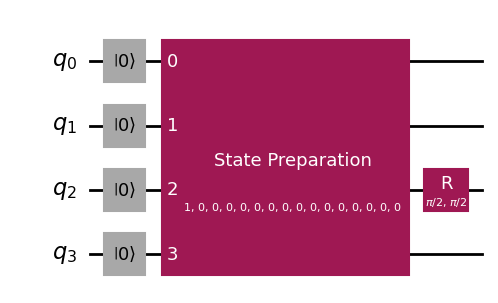

In [105]:
# figure out how to do this classically later. write function that applies spin matrix to middle two? or is it better to do this in the quantum circuiot and then trun it into classical vector?

#doing it quantumly:

qc = QuantumCircuit(int(L))
qc.initialize(initial) #initialize state

#apply rotation
middle = L //2 #picks L/2 int value
qc.ry(np.pi/2, middle) #rotation here is into x-y plane

initial = Statevector(qc)  #initial state, now rotated

qc.decompose().draw('mpl')

In [106]:
initial.draw('latex')

<IPython.core.display.Latex object>

In [107]:
#getting the vector for our state as an array
psi0 = np.array(initial)

In [108]:
#getting hamiltonian as a matrix
matrix_h = np.array(hm.hamiltonian1(L,Jz))

In [109]:
pauli_x = ((0,1),(1,0))
pauli_y = ((0,-1j),(1j,0))
pauli_z = ((1,0),(0,-1))

In [110]:
import functools as ft
product = [pauli_x,np.eye(2),np.eye(2),np.eye(2)]  #the kronecker product to build the obervable matrix
observable_m = ft.reduce(np.kron,product)

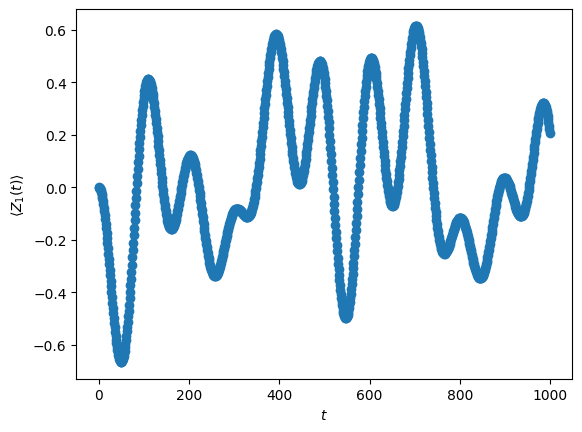

In [111]:
# Initialise an empty list to store the observables we compute
zlist = []

# Run a loop over timesteps
for t in range(1000):
    # Compute the time evolution operator that evolves the system to time t * 0.01
    Ut = sp.linalg.expm(- 1j * matrix_h * 0.01 * t)

    # Apply the time evolution operator to the initial state in order to construct |psi(t)>
    psi_t = Ut @ psi0

    # Compute the expectation value of the Z projection of one of the qubits

    

    zt = psi_t.T @ observable_m @ psi_t

    # Save the above expectation value to the list we created at the start
    # (It's safe to only keep the real part because all observables are Hermitian, meaning they have real expectation values)
    zlist += [zt.real]

plt.plot(zlist,'o-')
plt.xlabel(r'$t$')
plt.ylabel(r'$\langle Z_1(t) \rangle$')
plt.ylabel
plt.show()
plt.close()

The above code is measuring the $Z$ projection of the first qubit's spin:
$$\langle Z_1(t)\rangle=\langle\psi(t)|Z_1|\psi(t)\rangle$$
Now that this all works, we can turn it ito a function:

In [155]:
def ClassicalComparison(L,Jz,qubit_measured,direction_measured,steps=100,t_tot=1,allzeros=True):
    '''
    performs an expectation value measurement for a spin proj. in a certain direction on a certain qubit. Does this classically with matrix multiplication.
    (still need to make the initial state rotation classical) (rn, importing Hamiltonian.py as hm) (imports needed: scipy as sp, numpy as np, functools as ft)
    
    returns two np.arrays: ([time_values],[measurements])

    :param L: (int) number of qubits
    :param Jz: (float) J_z value 
    
    :param qubit_measured: (int) which qubit (1 to L) is measured
    :param direction_measured: (str) "X" "Y" or "Z", which projection operator is applied to the measured qubit
    :param steps: (int) number of time steps (auto set to 100)
    :param t_tot: (float) total time (in seconds? not seconds cause there are no hbars or cs) (auto set to 1)
    :param allzeros: (bool) if Jz>1, True chooses the all |0> state, False chooses the all |1> state
    '''
    #defining the Pauli matrices
    pauli_x = ((0,1),(1,0))
    pauli_y = ((0,-1j),(1j,0))
    pauli_z = ((1,0),(0,-1))

    #Hamiltonian as an np.array matrix
    matrix_h = np.array(hm.hamiltonian1(L,Jz))

    #getting initial state, according to Jz value
    if Jz > 1:
        all0, all1 = hm.initialise(Jz,L)[1]
        if allzeros==True:
            initial = all0
        else:
            initial = all1
    elif Jz < -1:
        initial = hm.initialise(Jz,L)[1][0]
    else:
        print('Please pick J_z > 1 or J_z < -1')
        return

    #rotating middle qubit's spin to x-y plane
    ### This is the quantum bit that i should figure out classically ###
    qc = QuantumCircuit(int(L))
    qc.initialize(initial) #initialize state
    #apply rotation
    middle = L //2 #picks L/2 int value
    qc.ry(np.pi/2, middle) #rotation here is into x-y plane
    initial = Statevector(qc)  #initial state, now rotated
    ###

    #getting the vector for our state as an np.array
    psi0 = np.array(initial)
    
    #choosing correct pauli matrix
    if direction_measured == "X" or direction_measured == "x":
        pauli = pauli_x
    elif direction_measured == "Y" or direction_measured == "y":
        pauli = pauli_y
    elif direction_measured == "Z" or direction_measured == "z":
        pauli = pauli_z
    else:
        print("Please choose strings 'X', 'Y', or 'Z' for direction_measured")
        return
    
    #creating our observable operator matrix, for our expectation value
    product = [np.eye(2) for i in range(L)]
    product[qubit_measured-1] = pauli         #list of matrices to kronecker product to build the obervable matrix
    observable_m = ft.reduce(np.kron,product) #does multiple kronecker products in a row (with matrices in list)

    # Initialise an empty list to store the observables we compute
    measurements = []

    #timestep
    dt = t_tot/steps

    # Run a loop over timesteps
    for t in range(steps):
        # Compute the time evolution operator that evolves the system to time t * 0.01
        Ut = sp.linalg.expm(- 1j * matrix_h * dt * t)

        # Apply the time evolution operator to the initial state in order to construct |psi(t)>
        psi_t = Ut @ psi0

        # Compute the expectation value of the Z projection of one of the qubits

        expval = psi_t.T @ observable_m @ psi_t

        # Save the above expectation value to the list we created at the start
        # (It's safe to only keep the real part because all observables are Hermitian, meaning they have real expectation values)
        measurements += [expval.real]
    
    t_values = np.array([dt*t for t in range(steps)])

    return (t_values,np.array(measurements))



For $J_z>1$ here $J_z=2$

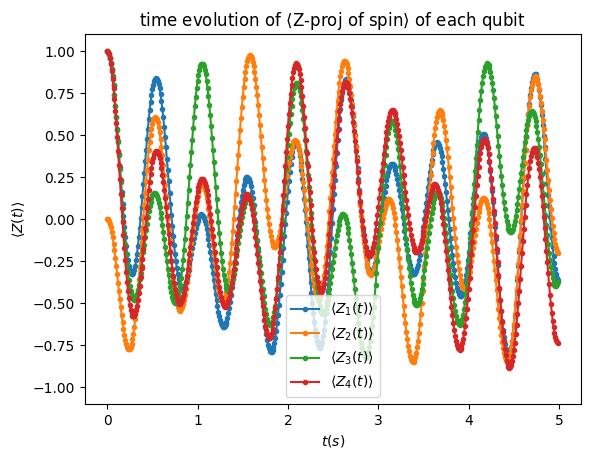

In [ ]:
# direction Z
L = 4
Jz = 2
direction = 'Z'
steps = 500
t_tot=5

#number is for the qubit measured
t1,x1 = ClassicalComparison(L,Jz,1,direction,steps,t_tot)
t2,x2 = ClassicalComparison(L,Jz,2,direction,steps,t_tot)
t3,x3 = ClassicalComparison(L,Jz,3,direction,steps,t_tot)
t4,x4 = ClassicalComparison(L,Jz,4,direction,steps,t_tot)


plt.plot(t1,x1,'.-',label=r'$\langle Z_1(t) \rangle$')
plt.plot(t2,x2,'.-',label=r'$\langle Z_2(t) \rangle$')
plt.plot(t3,x3,'.-',label=r'$\langle Z_3(t) \rangle$')
plt.plot(t4,x4,'.-',label=r'$\langle Z_4(t) \rangle$')

plt.xlabel(r'$t$ $(eV^{-1})$')
plt.ylabel(r'$\langle Z(t) \rangle$')
plt.legend()
plt.title(r'time evolution of $\langle$Z-proj of spin$\rangle$ of each qubit')
plt.ylim([-1.1,1.1])
plt.show()
plt.close()

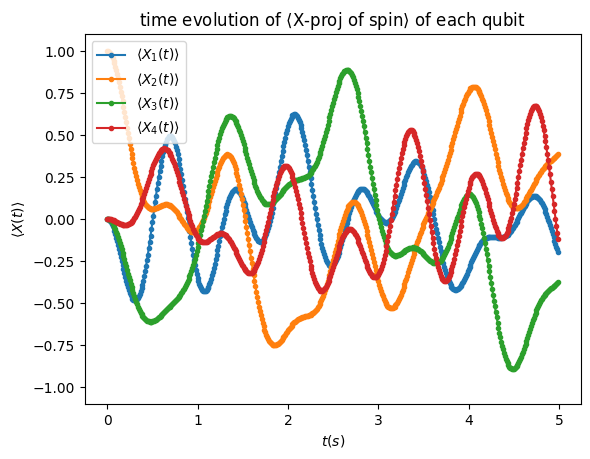

In [ ]:
# direction X
L = 4
Jz = 2
direction = 'X'
steps = 500
t_tot=5

#number is for the qubit measured
t1,x1 = ClassicalComparison(L,Jz,1,direction,steps,t_tot)
t2,x2 = ClassicalComparison(L,Jz,2,direction,steps,t_tot)
t3,x3 = ClassicalComparison(L,Jz,3,direction,steps,t_tot)
t4,x4 = ClassicalComparison(L,Jz,4,direction,steps,t_tot)


plt.plot(t1,x1,'.-',label=r'$\langle X_1(t) \rangle$')
plt.plot(t2,x2,'.-',label=r'$\langle X_2(t) \rangle$')
plt.plot(t3,x3,'.-',label=r'$\langle X_3(t) \rangle$')
plt.plot(t4,x4,'.-',label=r'$\langle X_4(t) \rangle$')

plt.xlabel(r'$t$ $(eV^{-1})$')
plt.ylabel(r'$\langle X(t) \rangle$')
plt.legend()
plt.title(r'time evolution of $\langle$X-proj of spin$\rangle$ of each qubit')
plt.ylim([-1.1,1.1])
plt.show()
plt.close()

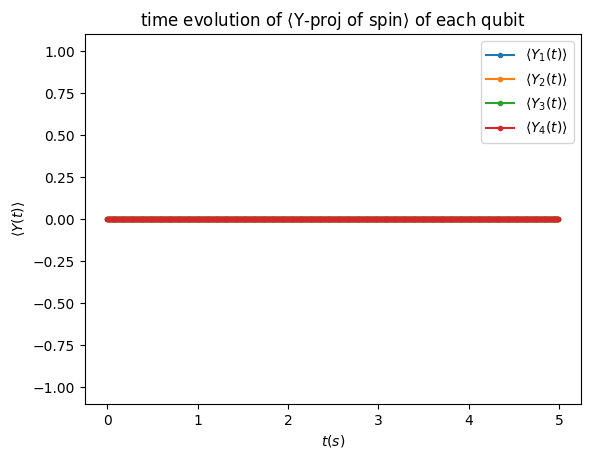

In [ ]:
# direction Y
L = 4
Jz = 2
direction = 'Y'
steps = 500
t_tot=5

#number is for the qubit measured
t1,x1 = ClassicalComparison(L,Jz,1,direction,steps,t_tot)
t2,x2 = ClassicalComparison(L,Jz,2,direction,steps,t_tot)
t3,x3 = ClassicalComparison(L,Jz,3,direction,steps,t_tot)
t4,x4 = ClassicalComparison(L,Jz,4,direction,steps,t_tot)


plt.plot(t1,x1,'.-',label=r'$\langle Y_1(t) \rangle$')
plt.plot(t2,x2,'.-',label=r'$\langle Y_2(t) \rangle$')
plt.plot(t3,x3,'.-',label=r'$\langle Y_3(t) \rangle$')
plt.plot(t4,x4,'.-',label=r'$\langle Y_4(t) \rangle$')

plt.xlabel(r'$t$ $(eV^{-1})$')
plt.ylabel(r'$\langle Y(t) \rangle$')
plt.legend()
plt.title(r'time evolution of $\langle$Y-proj of spin$\rangle$ of each qubit')
plt.ylim([-1.1,1.1])
plt.show()
plt.close()

Now for $J_z<-1$

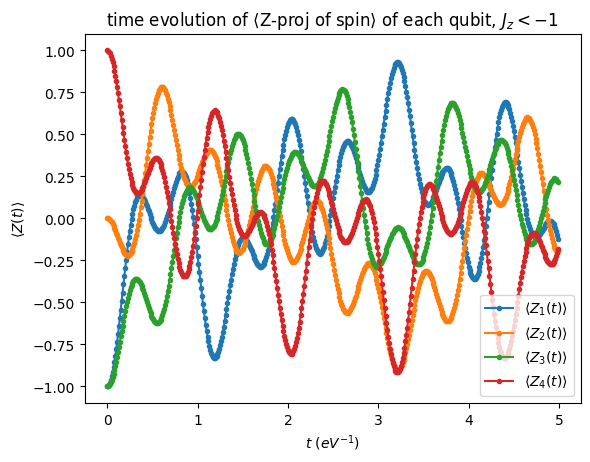

In [162]:
# direction Z
L = 4
Jz = -1.1
direction = 'Z'
steps = 500
t_tot=5

#number is for the qubit measured
t1,x1 = ClassicalComparison(L,Jz,1,direction,steps,t_tot)
t2,x2 = ClassicalComparison(L,Jz,2,direction,steps,t_tot)
t3,x3 = ClassicalComparison(L,Jz,3,direction,steps,t_tot)
t4,x4 = ClassicalComparison(L,Jz,4,direction,steps,t_tot)


plt.plot(t1,x1,'.-',label=r'$\langle Z_1(t) \rangle$')
plt.plot(t2,x2,'.-',label=r'$\langle Z_2(t) \rangle$')
plt.plot(t3,x3,'.-',label=r'$\langle Z_3(t) \rangle$')
plt.plot(t4,x4,'.-',label=r'$\langle Z_4(t) \rangle$')

plt.xlabel(r'$t$ $(eV^{-1})$')
plt.ylabel(r'$\langle Z(t) \rangle$')
plt.legend()
plt.title(r'time evolution of $\langle$Z-proj of spin$\rangle$ of each qubit, $J_z<-1$')
plt.ylim([-1.1,1.1])
plt.show()
plt.close()

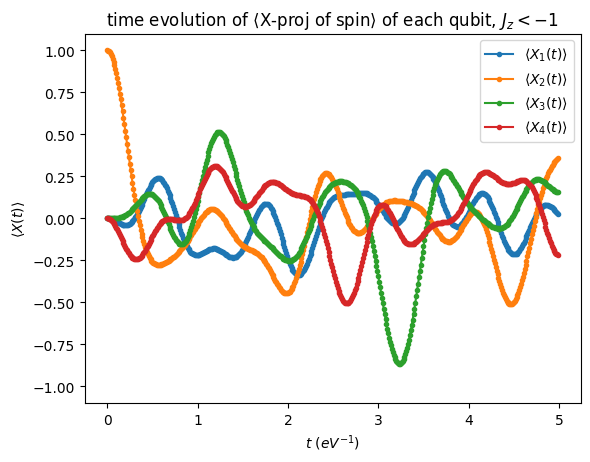

In [163]:
# direction X
L = 4
Jz = -1.1
direction = 'X'
steps = 500
t_tot=5

#number is for the qubit measured
t1,x1 = ClassicalComparison(L,Jz,1,direction,steps,t_tot)
t2,x2 = ClassicalComparison(L,Jz,2,direction,steps,t_tot)
t3,x3 = ClassicalComparison(L,Jz,3,direction,steps,t_tot)
t4,x4 = ClassicalComparison(L,Jz,4,direction,steps,t_tot)


plt.plot(t1,x1,'.-',label=r'$\langle X_1(t) \rangle$')
plt.plot(t2,x2,'.-',label=r'$\langle X_2(t) \rangle$')
plt.plot(t3,x3,'.-',label=r'$\langle X_3(t) \rangle$')
plt.plot(t4,x4,'.-',label=r'$\langle X_4(t) \rangle$')

plt.xlabel(r'$t$ $(eV^{-1})$')
plt.ylabel(r'$\langle X(t) \rangle$')
plt.legend()
plt.title(r'time evolution of $\langle$X-proj of spin$\rangle$ of each qubit, $J_z<-1$')
plt.ylim([-1.1,1.1])
plt.show()
plt.close()

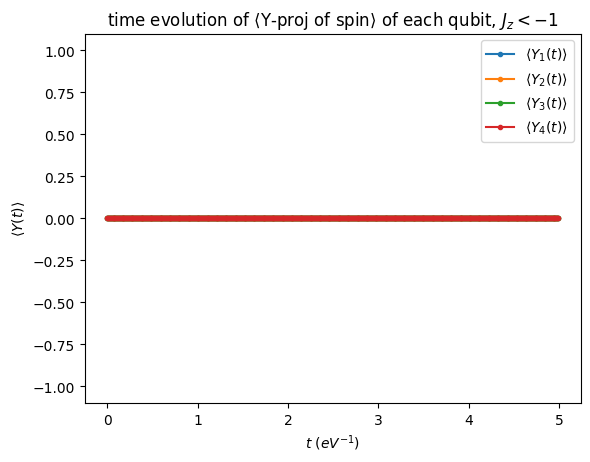

In [164]:
# direction Y
L = 4
Jz = -1.1
direction = 'Y'
steps = 500
t_tot=5

#number is for the qubit measured
t1,x1 = ClassicalComparison(L,Jz,1,direction,steps,t_tot)
t2,x2 = ClassicalComparison(L,Jz,2,direction,steps,t_tot)
t3,x3 = ClassicalComparison(L,Jz,3,direction,steps,t_tot)
t4,x4 = ClassicalComparison(L,Jz,4,direction,steps,t_tot)


plt.plot(t1,x1,'.-',label=r'$\langle Y_1(t) \rangle$')
plt.plot(t2,x2,'.-',label=r'$\langle Y_2(t) \rangle$')
plt.plot(t3,x3,'.-',label=r'$\langle Y_3(t) \rangle$')
plt.plot(t4,x4,'.-',label=r'$\langle Y_4(t) \rangle$')

plt.xlabel(r'$t$ $(eV^{-1})$')
plt.ylabel(r'$\langle Y(t) \rangle$')
plt.legend()
plt.title(r'time evolution of $\langle$Y-proj of spin$\rangle$ of each qubit, $J_z<-1$')
plt.ylim([-1.1,1.1])
plt.show()
plt.close()